# Парсинг драгметаллов

Для драг. металлов и валюты:
- engine: `currency`
- market: `selt`
- board: `cets`

Тикеры драгметаллов и валюты можно найти здесь: `https://iss.moex.com/iss/engines/currency/markets/selt/boards/CETS/securities`




In [57]:
from enum import Enum, IntEnum
from aiomoex import get_board_candles
import asyncio
import aiohttp
from datetime import datetime, timedelta, date
import pandas as pd


class Engines(Enum):
    """https://iss.moex.com/iss/engines"""

    STOCK = "stock"  # Фондовый рынок и рынок депозитов
    STATE = "state"  # Рынок ГЦБ (размещение)
    CURRENCY = "currency"  # Валютный рынок
    FUTURES = "futures"  # stockСрочный рынок
    COMMODITY = "commodity"  # Товарный рынок
    INTERVENTIONS = "interventions"  # Товарные интервенции
    OFFBOARD = "offboard"  # ОТС-система
    AGR = "agro"  # Агро
    OTC = "otc"  # ОТС с ЦК
    QUOTES = "quotes"  # Квоты
    MONEY = "money"  # Денежный рынок


class Markets(Enum):
    """https://iss.moex.com/iss/engines/<engine>/markets"""

    # engine=currency
    OTCINDICES = "otcindices"  # Внебиржевые индексы
    SELT = "selt"  # Биржевые сделки с ЦК
    FUTURES = "futures"  # Поставочные фьючерсы
    INDEX = "index"  # Валютный фиксинг
    OTC = "otc"  # Внебиржевой

    # engine=futures
    FORTS = "forts"  # Фьючерсы
    OPTIONS = "options"  # Опционы
    FORTSIQS = "fortsiqs"  # Фьючерсы IQS
    OPTIONSIQS = "optionsiqs"  # Опционы IQS
    MAIN = "main"  # Срочные инструменты


class Boards(Enum):
    """https://iss.moex.com/iss/engines/<engine>/markets/<market>/boards"""

    # engine=currency, market=selt
    TQBR = "TQBR"  # Фондовый рынок
    AUCB = "AUCB"  # Аукцион ЦБР - адрес.
    CETS = "CETS"  # Системные сделки - безадрес.
    CNGD = "CNGD"  # Внесистемные сделки- адрес.
    CURR = "CURR"  # Дневная сессия
    FIXN = "FIXN"  # Фиксинг внесистемный- адрес.
    FIXS = "FIXS"  # Фиксинг системный - безадрес.
    LICU = "LICU"  # Внесистемные сделки урегулирования - безадрес.
    SDBP = "SDBP"  # Крупные сделки - безадрес.
    SPEC = "SPEC"  # Поставка - безадресные
    WAPN = "WAPN"  # Внесистемные средневзвешенные - адрес.
    WAPS = "WAPS"  # Системные средневзвешенные - безадрес.

    # engine=futures, market=forts
    RFUD = "RFUD"  # Фьючерсы


class IntervalEnum(IntEnum):
    MINUTE = 1
    TEN_MINUTES = 10
    HOUR = 60
    DAY = 24
    WEEK = 7
    MONTH = 31


# объявим аннотацию для удобства
StockData = list[dict[str, str | int | float]]


async def fetch_ticker_data(
    session: aiohttp.ClientSession,
    ticker: str,
    interval: IntervalEnum,
    start_date: str,
    end_date: str,
    board: Boards,
    engine: Engines,
    market: Markets,
) -> dict[str, pd.DataFrame]:
    """Функция получает данные о торгах по заданному тикеру с *start_date* по *end_date* с интервалом *interval*, возвращая словарь, где ключом является тикер, а значением - данные

    Args:
        session (aiohttp.ClientSession): aiottp сессия для отпаравки запросов
        ticker (str): Имя тикера
        interval (IntervalEnum): Одно из доступных значений для интервала времени
        start_date (str): Начальная дата в формате yyyy-mm-dd
        end_date (str): Конечная дата в формате yyyy-mm-dd

    Returns:
        dict[str, list[dict[str, str | int | float]]]: Словарь, где ключ - тикер, а значение - данные, например {'SBER': sber_data}
    """
    try:
        # получаем данные по переданному тикеру за указанный период
        res = await get_board_candles(
            session,
            ticker,
            interval,
            start_date,
            end_date,
            board=board.value,
            market=market.value,
            engine=engine.value,
        )
        if res:
            df = pd.DataFrame(res)

            if "end" in df.columns:
                df = df.drop("end", axis=1)

            df["begin"] = pd.to_datetime(df["begin"])

            if interval in [24, 7, 31]:
                df["begin"] = df["begin"].dt.normalize()

            if "begin" in df.columns:
                cols = ["begin"] + [col for col in df.columns if col != "begin"]
                df = df[cols]

            df["ticker"] = ticker
            return {ticker: df}
        else:
            return {ticker: pd.DataFrame()}
    except Exception as e:
        print(f"Ошибка парсинга. Не удалось получить данные для {ticker}, {e}")
        return {ticker: pd.DataFrame()}


async def get_moex_data(
    tickers: list[str],
    start_date: datetime,
    end_date: datetime = datetime.now(),
    interval: IntervalEnum = IntervalEnum.DAY,
    engine: Engines = Engines.CURRENCY,
    market: Markets = Markets.SELT,
    board: Boards = Boards.CETS,
) -> dict[str, pd.DataFrame]:
    if interval not in IntervalEnum:
        raise ValueError(f"Неверный интервал. Допустимые значения: {IntervalEnum}")

    end_date_formatted = end_date.strftime("%Y-%m-%d %H:%M:%S")
    start_date_formatted = start_date.strftime("%Y-%m-%d %H:%M:%S")

    # Увеличиваем таймауты для MOEX API
    timeout = aiohttp.ClientTimeout(
        connect=30,  # время подключения
        sock_read=60,  # время чтения данных
        total=120,  # общий таймаут
    )

    async with aiohttp.ClientSession(timeout=timeout) as session:
        # собираем корутины в список
        coros = [
            fetch_ticker_data(
                session,
                ticker,
                interval,
                start_date_formatted,
                end_date_formatted,
                board,
                engine,
                market,
            )
            for ticker in tickers
        ]
        # 'собираем' результаты корутин - непосредственно парсинг
        stock_data = await asyncio.gather(*coros)

    # разворачиваем список словарей в один словарь, например: [ {'SBER': sber_data}, {'GAZP': gazp_data} ] -> { 'SBER': sber_data, 'GAZP': gazp_data }
    stock_data = {
        ticker: data for element in stock_data for ticker, data in element.items()
    }
    return stock_data

In [58]:
from dataclasses import dataclass


@dataclass
class Asset:
    """Общий класс для активов с нужными параметрами для получения данных с MOEX"""

    engine: Engines
    market: Markets
    board: Boards
    ticker: str

    async def get_candles(
        self, start_date: datetime, end_date: datetime, interval: IntervalEnum
    ) -> pd.DataFrame:
        data = await get_moex_data(
            tickers=[self.ticker],
            start_date=start_date,
            end_date=end_date,
            interval=interval,
            engine=self.engine,
            market=self.market,
            board=self.board,
        )
        return data[self.ticker]

    def __str__(self) -> str:
        return f"Актив: {self.ticker}. Параметры MOEX: engine={self.engine}, market={self.market}, board={self.board}"


In [59]:
gold = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="GLDRUB_TOM",
)
display(
    await gold.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,8453.6,8450.0,8493.1,8420.0,3.356545e+09,396090,GLDRUB_TOM
1,2025-05-14,8426.0,8325.0,8447.4,8270.0,2.026249e+09,242635,GLDRUB_TOM
2,2025-05-15,8251.0,8326.9,8330.0,8176.0,1.658114e+09,201332,GLDRUB_TOM
3,2025-05-16,8325.0,8340.0,8371.1,8252.0,2.959429e+09,355311,GLDRUB_TOM
4,2025-05-19,8408.0,8360.9,8425.0,8342.5,4.671974e+09,557720,GLDRUB_TOM
...,...,...,...,...,...,...,...,...
123,2025-11-01,10350.0,10410.0,10419.9,10310.6,1.226836e+09,118446,GLDRUB_TOM
124,2025-11-03,10421.6,10300.7,10474.0,10285.8,5.059804e+08,48784,GLDRUB_TOM
125,2025-11-05,10266.0,10369.9,10370.0,10250.0,7.480118e+09,723489,GLDRUB_TOM
126,2025-11-06,10405.2,10354.0,10478.4,10325.0,3.488334e+09,334933,GLDRUB_TOM


In [60]:
silver = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="SLVRUB_TOM",
)
display(
    await silver.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,120.62,121.08,123.39,120.16,21341015,175000,SLVRUB_TOM
1,2025-05-14,121.48,120.52,121.49,120.00,10787214,89300,SLVRUB_TOM
2,2025-05-15,120.11,119.61,120.11,118.20,16541976,138900,SLVRUB_TOM
3,2025-05-16,119.79,119.46,120.99,118.90,10892124,91000,SLVRUB_TOM
4,2025-05-19,119.45,118.09,119.69,118.01,13578233,114100,SLVRUB_TOM
...,...,...,...,...,...,...,...,...
123,2025-11-01,146.59,144.98,148.00,138.23,84600863,589200,SLVRUB_TOM
124,2025-11-03,146.00,149.19,150.80,146.00,67862826,454300,SLVRUB_TOM
125,2025-11-05,149.20,147.70,149.20,143.08,90098082,616000,SLVRUB_TOM
126,2025-11-06,149.19,143.54,152.80,141.93,159347488,1075000,SLVRUB_TOM


In [61]:
platinum = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="PLTRUB_TOM",
)
display(
    await platinum.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,2575.43,2588.99,2623.04,2550.00,7932917.19,3075,PLTRUB_TOM
1,2025-05-14,2588.88,2595.00,2620.99,2580.02,7653531.41,2949,PLTRUB_TOM
2,2025-05-15,2618.99,2595.61,2618.99,2576.31,2580331.03,997,PLTRUB_TOM
3,2025-05-16,2595.62,2616.90,2617.00,2595.62,7153373.16,2743,PLTRUB_TOM
4,2025-05-19,2626.00,2585.00,2626.00,2577.23,6730099.16,2594,PLTRUB_TOM
...,...,...,...,...,...,...,...,...
123,2025-11-01,4137.00,4181.04,4199.89,4121.01,2788093.27,671,PLTRUB_TOM
124,2025-11-03,4205.00,4090.00,4208.96,4070.11,7587814.92,1827,PLTRUB_TOM
125,2025-11-05,4099.89,4088.01,4117.24,3990.75,28709398.01,7060,PLTRUB_TOM
126,2025-11-06,4090.00,4080.00,4167.68,4001.00,34093424.05,8283,PLTRUB_TOM


In [62]:
palladium = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="PLDRUB_TOM",
)
display(
    await palladium.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,2514.00,2511.00,2520.00,2493.06,5534834.06,2208,PLDRUB_TOM
1,2025-05-14,2500.00,2511.64,2525.20,2500.00,3556770.73,1416,PLDRUB_TOM
2,2025-05-15,2525.00,2507.85,2525.00,2485.00,2539332.83,1013,PLDRUB_TOM
3,2025-05-16,2500.00,2499.04,2500.00,2490.00,885688.38,355,PLDRUB_TOM
4,2025-05-19,2500.00,2519.99,2527.10,2497.01,959111.74,382,PLDRUB_TOM
...,...,...,...,...,...,...,...,...
123,2025-11-01,3557.97,3574.99,3574.99,3484.02,3543400.66,1006,PLDRUB_TOM
124,2025-11-03,3574.99,3510.03,3587.99,3508.99,2936150.97,829,PLDRUB_TOM
125,2025-11-05,3508.99,3629.02,3655.99,3468.00,36452378.21,10272,PLDRUB_TOM
126,2025-11-06,3629.00,3574.99,3694.73,3544.19,31182963.74,8618,PLDRUB_TOM


# Нефть

In [63]:
# MOEX

# На MOEX нет индекса цены нефти, есть только фьючерсы.
# Список фьючерсов можно глянуть здесь:
# https://iss.moex.com/iss/engines/futures/markets/forts/boards/rfud/securities

BRENT_FUTURES = [
    "BRF6",  # 1.26
    "BRG6",  # 2.26
    "BRZ5",  # 12.25
]

for future_name in BRENT_FUTURES:
    print("Future:", future_name)
    brent_future = Asset(
        engine=Engines.FUTURES,
        market=Markets.FORTS,
        board=Boards.RFUD,
        ticker=future_name,
    )
    display(
        await brent_future.get_candles(
            start_date=datetime.now() - timedelta(days=180),
            end_date=datetime.now(),
            interval=IntervalEnum.DAY,
        )
    )


Future: BRF6


,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,67.00,68.00,68.00,67.00,0,4,BRF6
1,2025-05-14,68.43,67.90,68.43,67.90,0,7,BRF6
2,2025-05-15,66.60,66.73,66.73,65.89,0,6,BRF6
3,2025-05-16,66.73,65.02,66.81,65.02,0,8,BRF6
4,2025-05-19,66.84,67.00,67.00,66.82,0,3,BRF6
...,...,...,...,...,...,...,...,...
123,2025-11-01,63.78,64.20,64.25,63.63,0,1039,BRF6
124,2025-11-03,64.20,64.09,64.97,63.78,0,6857,BRF6
125,2025-11-05,64.32,63.98,64.64,63.56,0,19972,BRF6
126,2025-11-06,64.01,62.70,64.22,62.51,0,21425,BRF6


Future: BRG6


,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,67.33,67.99,67.99,67.33,0,2,BRG6
1,2025-05-14,68.33,68.33,68.33,68.33,0,2,BRG6
2,2025-05-15,68.23,68.23,68.23,68.23,0,1,BRG6
3,2025-05-16,67.17,64.34,68.23,64.34,0,12,BRG6
4,2025-05-19,67.23,66.98,67.23,66.98,0,4,BRG6
...,...,...,...,...,...,...,...,...
118,2025-11-01,63.48,63.84,63.84,63.38,0,54,BRG6
119,2025-11-03,63.84,63.63,64.35,63.46,0,697,BRG6
120,2025-11-05,63.80,63.51,64.35,63.29,0,1530,BRG6
121,2025-11-06,63.70,62.48,63.90,62.40,0,1508,BRG6


Future: BRZ5


,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,66.54,66.54,66.54,66.54,0,1,BRZ5
1,2025-05-14,67.28,67.00,68.00,67.00,0,107,BRZ5
2,2025-05-15,65.55,65.63,66.07,65.10,0,7,BRZ5
3,2025-05-16,65.71,66.01,66.01,65.71,0,2,BRZ5
4,2025-05-19,65.90,65.90,65.90,65.90,0,1,BRZ5
...,...,...,...,...,...,...,...,...
123,2025-11-01,64.34,64.76,64.87,64.20,0,39699,BRZ5
124,2025-11-03,64.75,64.57,65.60,64.32,0,149700,BRZ5
125,2025-11-05,64.65,64.37,65.20,63.97,0,237611,BRZ5
126,2025-11-06,64.40,63.00,64.67,62.83,0,360906,BRZ5


In [64]:
# API EIA (Управление энергетической информации США)

# Как пользоваться:
# 1. Зарегистрироваться и получить API ключ на почту: https://www.eia.gov/opendata/register.php
# 2. Сохранить API ключ в файл .env, переменная EIA_API_KEY
# 3. Включить VPN (с российского IP не пускает)
# 4. Запустить

import os
import sys
import time
from typing import Optional

import pandas as pd
import requests
from dotenv import load_dotenv

DEFAULT_FROM = "2022-04-01"
EIA_V2_URL = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
EIA_SERIES = "RBRTE"  # Europe Brent Spot Price FOB, $/bbl

session = requests.Session()
session.headers.update({"Accept": "application/json, text/*;q=0.8,*/*;q=0.5"})


def http_get(
    url: str, params: Optional[dict] = None, retries: int = 3, timeout: int = 30
) -> requests.Response:
    last = None
    for attempt in range(1, retries + 1):
        try:
            r = session.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception as e:
            last = e
            if attempt < retries:
                time.sleep(0.7 * attempt)
            else:
                raise
    raise last  # type: ignore


def fetch_brent_eia(d1: date, d2: date) -> pd.DataFrame:
    load_dotenv()
    api_key = os.getenv("EIA_API_KEY")
    if not api_key:
        raise RuntimeError(
            "EIA_API_KEY is not set. Get a free key at https://www.eia.gov/opendata/"
        )

    params = {
        "api_key": api_key,
        "frequency": "daily",
        "data[0]": "value",
        "facets[series][]": EIA_SERIES,
        "start": d1.isoformat(),
        "end": d2.isoformat(),
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
    }
    r = http_get(EIA_V2_URL, params=params)
    js = r.json()
    data = js.get("response", {}).get("data", [])
    print(data[:2])
    if not data:
        raise RuntimeError(f"EIA returned no data for {EIA_SERIES} in range {d1}..{d2}")
    df = pd.DataFrame(data)
    # expected fields: 'period' (YYYY-MM-DD), 'value' (float)
    df = df[["period", "value"]].rename(columns={"period": "date", "value": "value"})
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
    df["begin"] = df["date"].apply(
        lambda x: datetime.datetime.combine(
            x, datetime.time(hour=0, minute=0, second=0)
        )
    )
    df["end"] = df["date"].apply(
        lambda x: datetime.datetime.combine(
            x, datetime.time(hour=23, minute=59, second=59)
        )
    )
    df["value"] = df["value"].astype(float)
    del df["date"]
    df["ticker"] = EIA_SERIES
    return df


# Отключаем за ненадобностью
# df = fetch_brent_eia(datetime.date(2022, 4, 1), datetime.date(2025, 10, 28))
# display(df)


In [65]:
# df_csv = df.copy()
# df_csv['begin'] = df_csv['begin'].dt.strftime("%Y-%m-%d %H:%M:%S")
# df_csv['end'] = df_csv['end'].dt.strftime("%Y-%m-%d %H:%M:%S")
# df_csv.to_csv('data/brent_eia.csv')

In [66]:
# from matplotlib import pyplot as plt
# from matplotlib.ticker import FuncFormatter, MaxNLocator
# import matplotlib.dates as mdates
# plt.plot(df['begin'], df['value'])
# plt.ylabel('Price, $/bbl')
# plt.xlabel('Date')
# plt.title('Brent Crude Oil Price')
# plt.xticks(rotation=45)
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.MonthLocator())
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:.0f}'))
# ax.yaxis.set_major_locator(MaxNLocator(10))

# plt.show()

# Парсинг валют

Цены USD и EUR берем с сайта Центробанка РФ. Цены юаня можно взять на MOEX.

Курсы валют на определенный день: `https://www.cbr.ru/scripts/XML_daily.asp?date_req=28.10.2025` (выдает ближайшую дату, если по указанной дате нет данных)
Курсы валют за определенный период: `https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01/04/2022&date_req2=28/10/2025&VAL_NM_RQ=R01235`


In [67]:
# MOEX

# С MOEX удалось спарсить только цены юаня. Евро и доллар не торгуются на мосбирже.
# Вот, например, график пары USD/RUB. Последняя отметка 11.06.2024:
# https://www.moex.com/ru/issue/USD000UTSTOM/CETS
cnyrub = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="CNYRUB_TOM",
)
display(
    await cnyrub.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,11.1440,11.1180,11.1800,11.0955,8.232723e+10,7382943000,CNYRUB_TOM
1,2025-05-14,11.1200,11.0600,11.1450,11.0600,8.128886e+10,7314633000,CNYRUB_TOM
2,2025-05-15,11.1565,11.1170,11.1710,11.0835,6.243081e+10,5619479000,CNYRUB_TOM
3,2025-05-16,11.1170,11.1785,11.1990,11.1170,9.214677e+10,8254414000,CNYRUB_TOM
4,2025-05-19,11.1445,11.0790,11.1560,11.0665,7.210841e+10,6487034000,CNYRUB_TOM
...,...,...,...,...,...,...,...,...
123,2025-11-01,11.2500,11.3000,11.3200,11.1960,4.508962e+10,4005799000,CNYRUB_TOM
124,2025-11-03,11.3200,11.1550,11.3335,11.1450,1.349887e+10,1202831000,CNYRUB_TOM
125,2025-11-05,11.2370,11.3910,11.4275,11.2275,9.720605e+10,8569297000,CNYRUB_TOM
126,2025-11-06,11.4180,11.3240,11.4335,11.3000,7.073396e+10,6225997000,CNYRUB_TOM


In [68]:
# API Центробанка
# Здесь можно получить только цену за определенный день. Объема торгов нет, т.к. USD и EUR не торгуются на мосбирже.

from datetime import datetime
from typing import Dict
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from enum import Enum

# MOEX_DAILY_URL_TEMPLATE = "https://www.cbr.ru/scripts/XML_daily.asp?date_req={date}"
MOEX_DYNAMIC_URL_TEMPLATE = "https://cbr.ru/scripts/XML_dynamic.asp?date_req1={start}&date_req2={end}&VAL_NM_RQ={ticker}"


class MoexTicker(Enum):
    USDRUB = "R01235"
    EURRUB = "R01239"
    CNYRUB = "R01375"


def fetch_cbr_series(
    ticker: MoexTicker, start: datetime, end: datetime
) -> pd.DataFrame:
    """
    Fetch dynamic series for a currency by its VAL_NM_RQ (e.g., R01235) between start and end
    and return list of (date_iso, value_rub_per_1_unit).
    """
    url = MOEX_DYNAMIC_URL_TEMPLATE.format(
        ticker=ticker.value,
        start=start.strftime("%d/%m/%Y"),
        end=end.strftime("%d/%m/%Y"),
    )
    # CBR responds in windows-1251; use bytes and decode as needed
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    # Parse XML
    root = ET.fromstring(r.content)
    out: list[tuple[str, float]] = []
    for rec in root.findall("Record"):
        d_mdy = rec.attrib.get("Date")  # format: DD.MM.YYYY
        if not d_mdy:
            continue
        d_iso = datetime.strptime(d_mdy, "%d.%m.%Y").date().strftime("%Y-%m-%d")
        nominal_el = rec.find("Nominal")
        value_el = rec.find("Value")
        if nominal_el is None or value_el is None:
            continue
        try:
            nominal = int(nominal_el.text.strip())
        except Exception:
            nominal = 1
        # Decimal with comma
        value_txt = value_el.text.strip().replace(",", ".")
        rub_per_nominal = float(value_txt)
        rub_per_one = rub_per_nominal / nominal if nominal else rub_per_nominal
        out.append((d_iso, rub_per_one))
    # Drop duplicate dates keeping the last
    # (CBR should not duplicate, but be safe)
    out_dict: Dict[str, float] = {}
    for d, v in out:
        out_dict[d] = v

    out_sorted = sorted(out_dict.items(), key=lambda t: t[0])

    out_sorted = [
        (value, date + " 00:00:00", date + " 23:59:59", ticker.name)
        for date, value in out_sorted
    ]
    return pd.DataFrame(
        out_sorted, columns=["value", "date_start", "date_end", "ticker"]
    )


# Отключаем за ненадобностью
# display(fetch_cbr_series(MoexTicker.USDRUB, start=datetime(2022, 4, 1), end=datetime.now()))
# display(fetch_cbr_series(MoexTicker.EURRUB, start=datetime(2022, 4, 1), end=datetime.now()))
# display(fetch_cbr_series(MoexTicker.CNYRUB, start=datetime(2022, 4, 1), end=datetime.now()))

## Парсим цены фьючерсов, а не базового актива

Нефть, золото, USD и EUR не торгуются на бирже напрямую, поэтому мы не можем получить их цены. Но мы можем спарсить цены на фьючерсы по этим активам.

Для анализа подойдет "вечный" фьючерс: однодневный автоматически продлевающийся фьючерс.

In [69]:
usdrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на курс доллар США - российский рубль
    ticker="USDRUBF",
)
display(
    await usdrubf.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,80.99,80.74,81.52,80.70,0,97128,USDRUBF
1,2025-05-14,80.76,80.74,81.17,80.52,0,89477,USDRUBF
2,2025-05-15,81.30,80.69,81.30,80.39,0,95726,USDRUBF
3,2025-05-16,80.48,81.18,81.28,80.48,0,91695,USDRUBF
4,2025-05-19,81.23,80.51,81.36,80.31,0,100817,USDRUBF
...,...,...,...,...,...,...,...,...
123,2025-11-01,80.66,81.05,81.14,80.15,0,118214,USDRUBF
124,2025-11-03,80.98,80.16,81.08,80.00,0,123755,USDRUBF
125,2025-11-05,80.06,81.72,81.75,79.96,0,193093,USDRUBF
126,2025-11-06,81.73,81.30,81.91,81.03,0,145787,USDRUBF


In [70]:
from matplotlib import pyplot as plt


async def draw_currency_diagram(asset: Asset, start_date: datetime, end_date: datetime):
    df = await asset.get_candles(
        start_date=start_date, end_date=end_date, interval=IntervalEnum.DAY
    )
    fig, ax = plt.subplots()
    ax.plot(df["begin"], df["close"])
    plt.show()

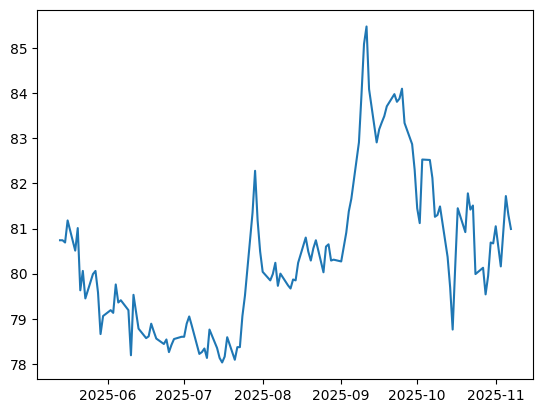

In [71]:
await draw_currency_diagram(
    usdrubf, datetime.now() - timedelta(days=180), datetime.now()
)

In [72]:
eurrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на курс евро - российский рубль
    ticker="EURRUBF",
)
display(
    await eurrubf.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,90.00,89.76,90.56,89.61,0,8662,EURRUBF
1,2025-05-14,89.80,90.26,90.69,89.67,0,10117,EURRUBF
2,2025-05-15,90.60,90.12,90.85,89.75,0,3750,EURRUBF
3,2025-05-16,89.99,90.81,91.21,89.92,0,10134,EURRUBF
4,2025-05-19,90.84,90.53,91.07,90.35,0,9333,EURRUBF
...,...,...,...,...,...,...,...,...
123,2025-11-01,92.82,93.44,93.49,92.44,0,3426,EURRUBF
124,2025-11-03,93.41,92.12,93.41,92.01,0,6937,EURRUBF
125,2025-11-05,92.16,93.86,93.87,92.07,0,12447,EURRUBF
126,2025-11-06,93.74,93.59,94.17,93.25,0,12881,EURRUBF


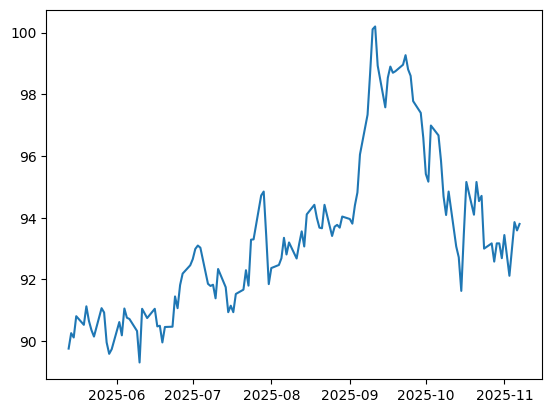

In [73]:
await draw_currency_diagram(
    eurrubf, datetime.now() - timedelta(days=180), datetime.now()
)

In [74]:
gldrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на золото
    ticker="GLDRUBF",
)
display(
    await gldrubf.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13,8415.0,8440.0,8501.6,8378.0,0,421763,GLDRUBF
1,2025-05-14,8459.1,8294.4,8483.8,8275.1,0,522208,GLDRUBF
2,2025-05-15,8217.0,8369.4,8373.8,8184.0,0,347609,GLDRUBF
3,2025-05-16,8334.2,8336.0,8411.9,8256.5,0,459397,GLDRUBF
4,2025-05-19,8344.3,8376.3,8462.2,8325.0,0,414251,GLDRUBF
...,...,...,...,...,...,...,...,...
125,2025-11-01,10390.8,10413.3,10425.9,10282.2,0,251290,GLDRUBF
126,2025-11-03,10409.3,10331.3,10464.8,10290.6,0,309515,GLDRUBF
127,2025-11-05,10322.8,10380.8,10392.0,10188.0,0,672504,GLDRUBF
128,2025-11-06,10381.4,10358.7,10497.9,10345.0,0,497576,GLDRUBF


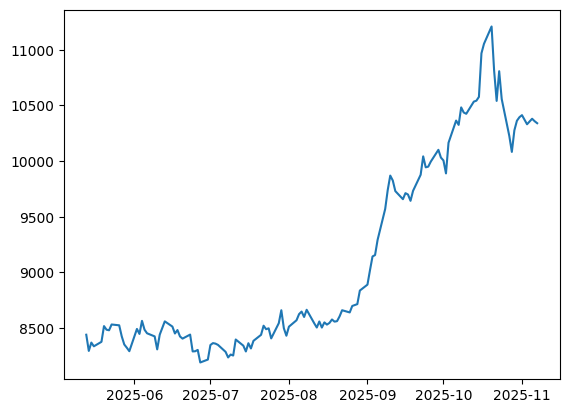

In [75]:
await draw_currency_diagram(
    gldrubf, datetime.now() - timedelta(days=180), datetime.now()
)

In [76]:
brf6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRF6",
)
brg6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRG6",
)
brh6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRH6",
)
brx5 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRX5",
)
brz6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRZ5",
)
print("brf6")
display(
    await brf6.get_candles(
        start_date=datetime.now() - timedelta(days=3),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)
print("brg6")
display(
    await brg6.get_candles(
        start_date=datetime.now() - timedelta(days=3),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)
print("brh6")
display(
    await brh6.get_candles(
        start_date=datetime.now() - timedelta(days=2),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)
print("brz6")
display(
    await brz6.get_candles(
        start_date=datetime.now() - timedelta(days=2),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

# По тикерам BRJ6, BRK6, BRM6, BRX5 данных нет
# brx5 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker="BRX5",
# )
# brj6 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker='BRJ6',
# )
# brk6 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker='BRK6',
# )
# brm6 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker='BRM6',
# )

brf6


,begin,open,close,high,low,value,volume,ticker
0,2025-11-06,64.01,62.70,64.22,62.51,0,21425,BRF6
1,2025-11-07,62.70,63.23,63.96,62.58,0,19159,BRF6


brg6


,begin,open,close,high,low,value,volume,ticker
0,2025-11-06,63.70,62.48,63.90,62.40,0,1508,BRG6
1,2025-11-07,62.52,62.90,63.58,62.42,0,495,BRG6


brh6


,begin,open,close,high,low,value,volume,ticker
0,2025-11-07,62.4,62.71,63.34,62.33,0,167,BRH6


brz6


,begin,open,close,high,low,value,volume,ticker
0,2025-11-07,63.02,63.59,64.35,62.94,0,291994,BRZ5


### Сравнение фьючерса на золото и спотового золота

In [77]:
# Сравним GLDRUB_TOM и GLDRUBF

df_gold = await gold.get_candles(
    start_date=datetime.now() - timedelta(days=180),
    end_date=datetime.now(),
    interval=IntervalEnum.HOUR,
)
df_gold_future = await gldrubf.get_candles(
    start_date=datetime.now() - timedelta(days=180),
    end_date=datetime.now(),
    interval=IntervalEnum.HOUR,
)
display(df_gold[:5])
display(df_gold_future[:5])

,begin,open,close,high,low,value,volume,ticker
0,2025-05-13 09:00:00,8453.6,8453.6,8453.6,8453.6,1098968.0,130,GLDRUB_TOM
1,2025-05-13 10:00:00,8454.0,8485.0,8489.9,8453.2,385961612.9,45493,GLDRUB_TOM
2,2025-05-13 11:00:00,8485.0,8480.0,8486.9,8460.0,285411284.5,33667,GLDRUB_TOM
3,2025-05-13 12:00:00,8480.1,8469.9,8490.0,8464.9,177844507.9,20989,GLDRUB_TOM
4,2025-05-13 13:00:00,8468.6,8480.5,8488.1,8466.5,440520074.4,51945,GLDRUB_TOM


,begin,open,close,high,low,value,volume,ticker
0,2025-05-13 08:00:00,8447.0,8447.0,8447.0,8447.0,0,151,GLDRUBF
1,2025-05-13 09:00:00,8447.0,8469.1,8475.0,8437.1,0,24973,GLDRUBF
2,2025-05-13 10:00:00,8468.9,8490.6,8500.0,8468.9,0,46963,GLDRUBF
3,2025-05-13 11:00:00,8491.0,8486.8,8493.9,8468.0,0,28556,GLDRUBF
4,2025-05-13 12:00:00,8488.0,8475.5,8501.6,8472.4,0,22839,GLDRUBF


In [78]:
print(f"GLDRUB_TOM dimensions: {df_gold.shape}")
print(f"GLDRUBF dimensions: {df_gold_future.shape}")

print(
    f"GLDRUB_TOM min/avg/max value: {df_gold['value'].min()}/{df_gold['value'].mean():.2f}/{df_gold['value'].max()}"
)
print(
    f"GLDRUBF min/avg/max value: {df_gold_future['value'].min()}/{df_gold_future['value'].mean():.2f}/{df_gold_future['value'].max()}"
)

print(
    f"GLDRUB_TOM open min/avg/max: {df_gold['open'].min()}/{df_gold['open'].mean():.2f}/{df_gold['open'].max()}"
)
print(
    f"GLDRUBF open min/avg/max: {df_gold_future['open'].min()}/{df_gold_future['open'].mean():.2f}/{df_gold_future['open'].max()}"
)

print(
    f"GLDRUB_TOM high min/avg/max: {df_gold['high'].min()}/{df_gold['high'].mean():.2f}/{df_gold['high'].max()}"
)
print(
    f"GLDRUBF high min/avg/max: {df_gold_future['high'].min()}/{df_gold_future['high'].mean():.2f}/{df_gold_future['high'].max()}"
)

print(
    f"GLDRUB_TOM low min/avg/max: {df_gold['low'].min()}/{df_gold['low'].mean():.2f}/{df_gold['low'].max()}"
)
print(
    f"GLDRUBF low min/avg/max: {df_gold_future['low'].min()}/{df_gold_future['low'].mean():.2f}/{df_gold_future['low'].max()}"
)

print(
    f"GLDRUB_TOM close min/avg/max: {df_gold['close'].min()}/{df_gold['close'].mean():.2f}/{df_gold['close'].max()}"
)
print(
    f"GLDRUBF close min/avg/max: {df_gold_future['close'].min()}/{df_gold_future['close'].mean():.2f}/{df_gold_future['close'].max()}"
)

print(
    f"GLDRUB_TOM volume min/avg/max: {df_gold['volume'].min()}/{df_gold['volume'].mean():.2f}/{df_gold['volume'].max()}"
)
print(
    f"GLDRUBF volume min/avg/max: {df_gold_future['volume'].min()}/{df_gold_future['volume'].mean():.2f}/{df_gold_future['volume'].max()}"
)

print(f"GLDRUB_TOM date range: {df_gold['begin'].min()}/{df_gold['begin'].max()}")
print(
    f"GLDRUBF date range: {df_gold_future['begin'].min()}/{df_gold_future['begin'].max()}"
)


GLDRUB_TOM dimensions: (1280, 8)
GLDRUBF dimensions: (2227, 8)
GLDRUB_TOM min/avg/max value: 17144.0/377528331.21/3303037042.299999
GLDRUBF min/avg/max value: 0/0.00/0
GLDRUB_TOM open min/avg/max: 8175.0/9094.25/11300.0
GLDRUBF open min/avg/max: 8183.9/9154.01/11306.2
GLDRUB_TOM high min/avg/max: 8193.5/9111.07/11370.0
GLDRUBF high min/avg/max: 8198.8/9169.92/11377.4
GLDRUB_TOM low min/avg/max: 8165.0/9076.46/11288.2
GLDRUBF low min/avg/max: 8109.9/9137.89/11270.8
GLDRUB_TOM close min/avg/max: 8175.0/9094.27/11288.2
GLDRUBF close min/avg/max: 8184.2/9154.51/11305.6
GLDRUB_TOM volume min/avg/max: 2/40815.04/363066
GLDRUBF volume min/avg/max: 1/27702.25/366704
GLDRUB_TOM date range: 2025-05-13 09:00:00/2025-11-07 18:00:00
GLDRUBF date range: 2025-05-13 08:00:00/2025-11-08 18:00:00


In [79]:
# Нарисуем график времени торгов за прошедший месяц
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

df_gold_last_month = df_gold[
    df_gold["begin"] >= datetime.fromisoformat("2025-10-01")
].copy()
df_gold_future_last_month = df_gold_future[
    df_gold_future["begin"] >= datetime.fromisoformat("2025-10-01")
].copy()

df_gold_last_month_grouped = (
    df_gold_last_month.groupby(df_gold_last_month["begin"].dt.date.rename("date"))
    .agg({"begin": ["min", "max"]})
    .reset_index()
)
df_gold_last_month_grouped.columns = [
    "date",
    "begin_min",
    "begin_max",
]
df_gold_last_month_grouped["date"] = pd.to_datetime(df_gold_last_month_grouped["date"])
for col in ["begin_min", "begin_max"]:
    df_gold_last_month_grouped[col] = pd.to_datetime(
        df_gold_last_month_grouped[col]
    ).dt.time
df_gold_last_month_grouped["begin_min"] = df_gold_last_month_grouped["begin_min"].apply(
    lambda t: datetime.combine(datetime.min, t)
)
df_gold_last_month_grouped["begin_max"] = df_gold_last_month_grouped["begin_max"].apply(
    lambda t: datetime.combine(datetime.min, t)
)

display(df_gold_last_month_grouped[:5])

df_gold_future_last_month_grouped = (
    df_gold_future_last_month.groupby(
        df_gold_future_last_month["begin"].dt.date.rename("date")
    )
    .agg({"begin": ["min", "max"]})
    .reset_index()
)
df_gold_future_last_month_grouped.columns = [
    "date",
    "begin_min",
    "begin_max",
]
df_gold_future_last_month_grouped["date"] = pd.to_datetime(
    df_gold_future_last_month_grouped["date"]
)
for col in ["begin_min", "begin_max"]:
    df_gold_future_last_month_grouped[col] = pd.to_datetime(
        df_gold_future_last_month_grouped[col]
    ).dt.time
df_gold_future_last_month_grouped["begin_min"] = df_gold_future_last_month_grouped[
    "begin_min"
].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_future_last_month_grouped["begin_max"] = df_gold_future_last_month_grouped[
    "begin_max"
].apply(lambda t: datetime.combine(datetime.min, t))

display(df_gold_future_last_month_grouped[:5])


,date,begin_min,begin_max
0,2025-10-01,0001-01-01 09:00:00,0001-01-01 18:00:00
1,2025-10-02,0001-01-01 09:00:00,0001-01-01 18:00:00
2,2025-10-03,0001-01-01 09:00:00,0001-01-01 18:00:00
3,2025-10-06,0001-01-01 09:00:00,0001-01-01 18:00:00
4,2025-10-07,0001-01-01 09:00:00,0001-01-01 18:00:00


,date,begin_min,begin_max
0,2025-10-01,0001-01-01 08:00:00,0001-01-01 23:00:00
1,2025-10-02,0001-01-01 08:00:00,0001-01-01 23:00:00
2,2025-10-03,0001-01-01 08:00:00,0001-01-01 23:00:00
3,2025-10-04,0001-01-01 09:00:00,0001-01-01 18:00:00
4,2025-10-05,0001-01-01 09:00:00,0001-01-01 18:00:00


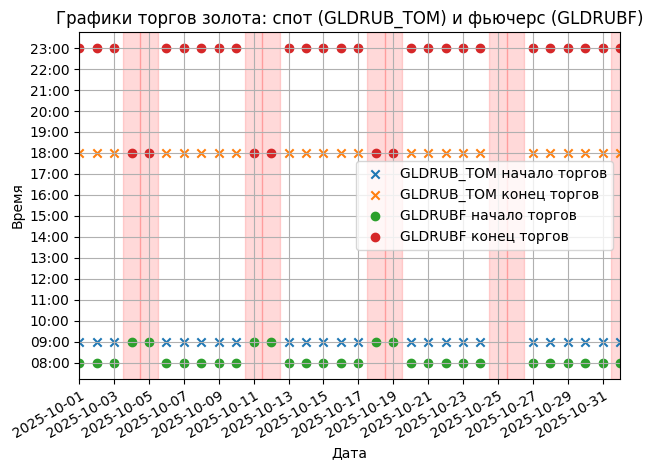

In [80]:
fig, ax = plt.subplots()

# Highlight weekends
start = pd.Timestamp("2025-10-01")
end_exclusive = pd.Timestamp("2025-11-01")
for day in pd.date_range(start, end_exclusive, freq="D"):
    if day.weekday() >= 5:  # 5=Sat, 6=Sun
        ax.axvspan(
            day - pd.Timedelta(hours=12),
            day + pd.Timedelta(hours=12),
            color="red",
            alpha=0.15,
            zorder=-1,
        )

ax.scatter(
    df_gold_last_month_grouped["date"],
    df_gold_last_month_grouped["begin_min"],
    marker="x",
    label="GLDRUB_TOM начало торгов",
)
ax.scatter(
    df_gold_last_month_grouped["date"],
    df_gold_last_month_grouped["begin_max"],
    marker="x",
    label="GLDRUB_TOM конец торгов",
)
ax.scatter(
    df_gold_future_last_month_grouped["date"],
    df_gold_future_last_month_grouped["begin_min"],
    marker="o",
    label="GLDRUBF начало торгов",
)
ax.scatter(
    df_gold_future_last_month_grouped["date"],
    df_gold_future_last_month_grouped["begin_max"],
    marker="o",
    label="GLDRUBF конец торгов",
)

# Set NaN for every missing day
df_gold_last_month_grouped["begin_min"] = df_gold_last_month_grouped[
    "begin_min"
].fillna(pd.NaT)
df_gold_last_month_grouped["begin_max"] = df_gold_last_month_grouped[
    "begin_max"
].fillna(pd.NaT)

# Format X axis (dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

# Format Y axis (times)
ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))

ax.set_xlim(start, end_exclusive)

for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_x(-0.05)
    label.set_rotation_mode("anchor")

plt.xticks(rotation=30)
plt.xlabel("Дата")
plt.ylabel("Время")
plt.title("Графики торгов золота: спот (GLDRUB_TOM) и фьючерс (GLDRUBF)")
plt.grid()
plt.legend(loc="right")
plt.tight_layout()
plt.show()

Вывод:
- Торги на споте мосбиржи начинаются в 9:00 и заканчиваются в 18:00. Торги проводятся только в будни.
- Торги фьючерсами проводятся каждый день. В будни (основная сессия + вечерняя сессия) торги начинаются в 8:00 и заканчиваются в 00:00. В выходные (дополнительная сессия выходного дня) торги начинаются в 9:00 и заканчиваются в 19:00.

25-26 октября были тех. работы, поэтому торги не проводились: https://www.moex.com/n94725

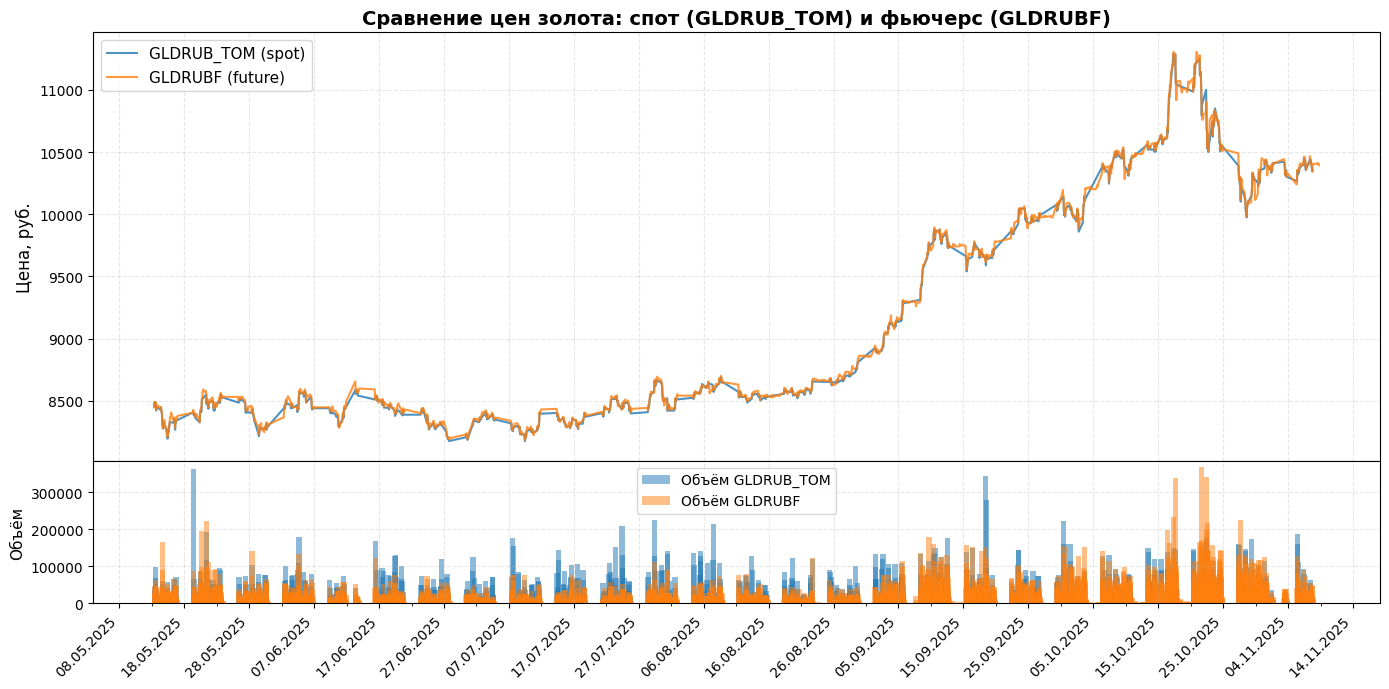

In [81]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df_gold["begin"] = pd.to_datetime(df_gold["begin"])
df_gold_future["begin"] = pd.to_datetime(df_gold_future["begin"])

df_gold_sorted = df_gold.sort_values("begin")
df_gold_future_sorted = df_gold_future.sort_values("begin")

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0)

# ---- PRICE AXIS ----
ax_price = fig.add_subplot(gs[0])

ax_price.plot(
    df_gold_sorted["begin"],
    df_gold_sorted["close"],
    label="GLDRUB_TOM (spot)",
    alpha=0.8,
    linewidth=1.5,
)

ax_price.plot(
    df_gold_future_sorted["begin"],
    df_gold_future_sorted["close"],
    label="GLDRUBF (future)",
    alpha=0.8,
    linewidth=1.5,
)

ax_price.set_ylabel("Цена, руб.", fontsize=12)
ax_price.set_title(
    "Сравнение цен золота: спот (GLDRUB_TOM) и фьючерс (GLDRUBF)",
    fontsize=14,
    fontweight="bold",
)
ax_price.legend(loc="best", fontsize=11)
ax_price.grid(True, alpha=0.3, linestyle="--")

# ---- VOLUME AXIS ----
ax_vol = fig.add_subplot(gs[1], sharex=ax_price)

# Spot volume (blue)
ax_vol.bar(
    df_gold_sorted["begin"],
    df_gold_sorted["volume"],
    width=0.8,
    alpha=0.5,
    label="Объём GLDRUB_TOM",
)

# Future volume (orange)
ax_vol.bar(
    df_gold_future_sorted["begin"],
    df_gold_future_sorted["volume"],
    width=0.8,
    alpha=0.5,
    label="Объём GLDRUBF",
)

ax_vol.set_ylabel("Объём", fontsize=11)
ax_vol.grid(True, alpha=0.3, linestyle="--")
ax_vol.legend(loc="best", fontsize=10)

# ---- X axis formatting ----
ax_vol.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))
ax_vol.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
plt.setp(ax_price.get_xticklabels(), visible=False)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Вывод:
- цены на спот золото и на фьючерс по золоту не сильно отличаются.
- фьючерс торгуется каждый день, даже в выходные, поэтому он может быть удобен для технического анализа.
- во фьючерсе меньше средний объем торгов, чем на споте. Однако за последний месяц объем торгов во фьючерсе выше, чем на споте, в связи с ростом интереса к золоту.

## Итог
- Удалось спарсить с мосбиржи данные по доллару, евро, юаню, золоту (и другим драгметаллам), нефти.
- Доллар, евро и нефть не торгуются на мосбирже, поэтому для анализа лучше использовать фьючерсы.
- Для анализа золота может подойти как фьючерс, так и спот. Стоимость фьючерса отличается от спота, но фьючерс торгуется в вечернюю и выходные сессии. При анализе стоит выбрать наиболее подходящий актив.

In [82]:
# Готовые для парсинга активы

# Золото
gold = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="GLDRUB_TOM",
)

# Фьючерс на золото
gldrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="GLDRUBF",
)

# Фьючерс USD/RUB
usdrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="USDRUBF",
)

# Фьючерс EUR/RUB
eurrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="EURRUBF",
)

# Спот CNY/RUB
cnyrub = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="CNYRUB_TOM",
)

# Фьючерсы на нефть Brent
brf6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRF6",
)
brg6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRG6",
)
brh6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRH6",
)
brz6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRZ5",
)

for a in [gold, gldrubf, brf6, brg6, brh6, brz6, usdrubf, eurrubf, cnyrub]:
    try:
        print(a.ticker)
        df = await a.get_candles(
            start_date=datetime.now() - timedelta(days=3),
            end_date=datetime.now(),
            interval=IntervalEnum.HOUR,
        )
        display(df[:3])
    except Exception as e:
        print(f"{a.ticker} error: {e}")


GLDRUB_TOM


,begin,open,close,high,low,value,volume,ticker
0,2025-11-06 09:00:00,10405.2,10405.2,10405.2,10405.2,11393694.0,1095,GLDRUB_TOM
1,2025-11-06 10:00:00,10408.0,10415.0,10440.0,10381.9,972366124.3,93432,GLDRUB_TOM
2,2025-11-06 11:00:00,10415.0,10446.1,10478.4,10412.1,833479262.7,79793,GLDRUB_TOM


GLDRUBF


,begin,open,close,high,low,value,volume,ticker
0,2025-11-06 08:00:00,10399.0,10399.0,10399.0,10399.0,0,1,GLDRUBF
1,2025-11-06 09:00:00,10394.7,10426.8,10429.9,10357.0,0,21798,GLDRUBF
2,2025-11-06 10:00:00,10428.0,10432.8,10462.2,10401.0,0,90206,GLDRUBF


BRF6


...

,begin,open,close,high,low,value,volume,ticker
0,2025-11-06 08:00:00,81.71,81.71,81.71,81.71,0,66,USDRUBF
1,2025-11-06 09:00:00,81.72,81.77,81.80,81.48,0,10068,USDRUBF
2,2025-11-06 10:00:00,81.77,81.52,81.91,81.27,0,29467,USDRUBF


EURRUBF


,begin,open,close,high,low,value,volume,ticker
0,2025-11-06 09:00:00,93.82,93.97,94.00,93.82,0,807,EURRUBF
1,2025-11-06 10:00:00,93.97,93.78,94.17,93.56,0,4464,EURRUBF
2,2025-11-06 11:00:00,93.78,93.70,93.95,93.70,0,531,EURRUBF


CNYRUB_TOM


,begin,open,close,high,low,value,volume,ticker
0,2025-11-06 09:00:00,11.4180,11.4180,11.4180,11.4180,1.198890e+06,105000,CNYRUB_TOM
1,2025-11-06 10:00:00,11.4125,11.3790,11.4335,11.3400,1.801033e+10,1582467000,CNYRUB_TOM
2,2025-11-06 11:00:00,11.3785,11.3675,11.3985,11.3645,8.560045e+09,752135000,CNYRUB_TOM
